In [1]:
import numpy as np
import tifffile
import pandas as pd
import matplotlib.pyplot as plt
import os
import glob

In [8]:
%matplotlib widget

In [2]:
import pyFAI
import numpy.ma as ma

def iq_saver(fn, df, md, header=("#q_A^-1", "I(q)")):

    with open(fn, mode="w", encoding="utf-8") as f:
        f.write("# pyFai_poni_information_28ID1_NSLS2_BNL\n")
        num_row = 1
        for key, value in md.items():
            f.write(f"# {key} {value}\n")
            num_row += 1

    ## Now append the dataframe
    df.to_csv(
        fn,
        encoding="utf-8",
        mode="a",
        header=header,
        index=False,
        float_format="{:.8e}".format,
        sep=" ",
    )

    ## return the number of rows of the header
    return num_row


def q_to_twotheta(q_array, wavelength):
    twotheta_radian = 2 * np.arcsin(q_array*wavelength/(4*np.pi))
    return np.degrees(twotheta_radian)


class img_integrate():

    def __init__(self, *args, 
                 poni_fn:str = None, 
                 mask_fn:str = None, 
                 output_dir:str = None,
                 file_name_prefix:str = None, 
                 wavelength:float = 0.1665, 
                 npt_rad:int = 4096,
                 npt_azim:int = 3600,
                 polarization:float = 0.99, 
                 UNIT:str = "q_A^-1", 
                 low_limit_pcfilter:float = 2.0, 
                 up_limit_pcfilter:float = 98.0,              
                 **kwargs):
        # super().__init__(*args, **kwargs)

        self.poni_fn = poni_fn
        self.mask_fn = mask_fn
        self.output_dir = output_dir
        self.file_name_prefix = file_name_prefix
        self.wavelength = wavelength
        self.npt_rad = npt_rad
        self.npt_azim = npt_azim
        self.polarization = polarization
        self.UNIT = UNIT
        self.ll = low_limit_pcfilter
        self.ul = up_limit_pcfilter   
        self.num_rows_header = 1
        self.ai = None


    @property
    def mask_array(self):
        return np.load(self.mask_fn)



    def pct_integration(self, image_fn:str):

        self.ai = pyFAI.load(self.poni_fn)
        image_array = tifffile.imread(image_fn)
        
        ## perform azimuthalintegration on one image to retain 2D information
        ## i2d.shape is (self.npt_azim, self.npt_rad) which corresponds the intensity of 2D image cake
        ## q1d.shape is (self.npt_rad, )
        i2d, q1d, chi1d = self.ai.integrate2d(image_array, self.npt_rad, 
                                         unit=self.UNIT, npt_azim=self.npt_azim, 
                                         polarization_factor=self.polarization, )
                                        #  mask=self.mask_array) 
        
        ## trasnform self.mask_array (base mask) to the same coordinate space and cast it as type bool
        intrinsic_mask_unrolled, _, _ = self.ai.integrate2d(self.mask_array, self.npt_rad, 
                                                       unit=self.UNIT, npt_azim=self.npt_azim, 
                                                       polarization_factor=self.polarization, )
                                                    #    mask=self.mask_array)
        #intrinsic_mask_unrolled = intrinsic_mask_unrolled.astype(bool) 
        
        ## Create an array to hold outlier mask
        outlier_mask_2d = np.zeros_like(i2d)     
        mask1 = np.array(i2d<1)*1
        
        ## Apply percentile filter along radial direction (axis=0)
        for ii, dd in enumerate(i2d.T):
            low_limit, high_limit = np.percentile(dd, (self.ll, self.ul))
            outlier_mask_2d[:,ii] = np.any([dd<low_limit, dd>high_limit, intrinsic_mask_unrolled[:,ii]], axis=0)
          
        outlier_mask_2d_masked = ma.masked_array(i2d, mask=outlier_mask_2d + mask1)
        
        ## calculate mean values along radial direction (axis=0) to make i1d.shape is (self.npt_rad, )
        i1d = ma.mean(outlier_mask_2d_masked, axis=0)
        
        ## export as q data
        iq_df0 = pd.DataFrame()
        iq_df0['q'] = q1d
        iq_df0['I'] = i1d
        # iq_df = iq_df0.dropna()
        iq_df = iq_df0.fillna(0)
        
        ## export as two-theta data
        iq_df1 = pd.DataFrame()
        iq_df1['tth'] = q_to_twotheta(q1d, self.wavelength) 
        iq_df1['I'] = i1d
        # iq_df = iq_df0.dropna()
        iq_df10 = iq_df1.fillna(0)
        
        md = self.ai.getPyFAI()
        _md = {
            # 'detector': self.run.start['detectors'][0], 
            # 'uid':self.full_uid, 
            # 'time': self.run.start['time'], 
            # 'readable_time': self.readable_time, 
            'wavelength': f'{self.wavelength} (A)', 
            'npt_rad': self.npt_rad, 
            'npt_azim': self.npt_azim, 
            'polarization': self.polarization, 
            'percentile_low_limit': self.ll, 
            'percentile_up_limit': self.ul, 
            # self.T_controller: self.temperature, 
        }
        md.update(_md)

        if self.file_name_prefix is None:
            self.file_name_prefix = os.path.basename(image_fn).split('.')[0]
            
        if self.output_dir is None:
            self.output_dir = os.path.dirname(image_fn)
            
        os.makedirs(self.output_dir, exist_ok=True)
        
        iq_fn = os.path.join(self.output_dir, f'{self.file_name_prefix}_sub.iq')
        tth_fn = os.path.join(self.output_dir, f'{self.file_name_prefix}_sub.xy')
        
        ## num_row will be the number of rows of the header in saved iq data file
        iq_saver(iq_fn, iq_df, md)
        iq_saver(tth_fn, iq_df10, md, header=['tth', 'I(q)'])
        print(f'\n*** {os.path.basename(iq_fn)} saved!! ***\n')
        print(f'\n*** {os.path.basename(tth_fn)} saved!! ***\n')

        # return iq_df, iq_fn, outlier_mask_2d_masked
        return iq_df, iq_fn

In [3]:
tiff_base_dir = "/nsls2/data/pdf/proposals/2026-2/pass-320443/Song_319127_6c143937/tiff_base"
img_list = glob.glob(os.path.join(tiff_base_dir, 'EL_WOCl2*', '*', 'img', '*tiff'))

In [4]:
img_list

['/nsls2/data/pdf/proposals/2026-2/pass-320443/Song_319127_6c143937/tiff_base/EL_WOCl2_powder_PDF/pilatus-1/img/EL_WOCl2_powder_PDF_20260724-111525_ca2569_319C_sum.tiff',
 '/nsls2/data/pdf/proposals/2026-2/pass-320443/Song_319127_6c143937/tiff_base/EL_WOCl2_powder_XRD/pe1/img/EL_WOCl2_powder_XRD_20260724-111914_fa84fb_320C_sub.tiff',
 '/nsls2/data/pdf/proposals/2026-2/pass-320443/Song_319127_6c143937/tiff_base/EL_WOCl2_powder_take2_PDF/pilatus-1/img/EL_WOCl2_powder_take2_PDF_20260724-122020_463bc0_320C_sum.tiff',
 '/nsls2/data/pdf/proposals/2026-2/pass-320443/Song_319127_6c143937/tiff_base/EL_WOCl2_powder_take2_XRD/pe1/img/EL_WOCl2_powder_take2_XRD_20260724-122408_c4a951_320C_sub.tiff']

In [5]:
poni_fn = os.path.join(tiff_base_dir, 'processed_chl', '*config', 'xpdAcq_calib_info.poni')
poni_list = glob.glob(poni_fn)
poni_list.sort()

mask_fn = os.path.join(tiff_base_dir, 'processed_chl', '*config', 'Mask*.npy')
mask_list = glob.glob(mask_fn)
mask_list.sort()

In [6]:
print(poni_list)
print(mask_list)

['/nsls2/data/pdf/proposals/2026-2/pass-320443/Song_319127_6c143937/tiff_base/processed_chl/PDF_config/xpdAcq_calib_info.poni', '/nsls2/data/pdf/proposals/2026-2/pass-320443/Song_319127_6c143937/tiff_base/processed_chl/XRD_config/xpdAcq_calib_info.poni']
['/nsls2/data/pdf/proposals/2026-2/pass-320443/Song_319127_6c143937/tiff_base/processed_chl/PDF_config/Mask_stitched.npy', '/nsls2/data/pdf/proposals/2026-2/pass-320443/Song_319127_6c143937/tiff_base/processed_chl/XRD_config/Mask.npy']


In [7]:
output_dir = os.path.join(tiff_base_dir, 'processed_chl')

for i, tiff in enumerate(img_list):
    if 'PDF' in os.path.basename(tiff):
        config_idx = 0
    elif 'XRD' in os.path.basename(tiff):
        config_idx = 1

    iii = img_integrate(
        poni_fn=poni_list[config_idx], 
        mask_fn=mask_list[config_idx], 
        output_dir=output_dir)
    
    iq_df, _ = iii.pct_integration(tiff)


*** EL_WOCl2_powder_PDF_20260724-111525_ca2569_319C_sum_sub.iq saved!! ***


*** EL_WOCl2_powder_PDF_20260724-111525_ca2569_319C_sum_sub.xy saved!! ***


*** EL_WOCl2_powder_XRD_20260724-111914_fa84fb_320C_sub_sub.iq saved!! ***


*** EL_WOCl2_powder_XRD_20260724-111914_fa84fb_320C_sub_sub.xy saved!! ***


*** EL_WOCl2_powder_take2_PDF_20260724-122020_463bc0_320C_sum_sub.iq saved!! ***


*** EL_WOCl2_powder_take2_PDF_20260724-122020_463bc0_320C_sum_sub.xy saved!! ***


*** EL_WOCl2_powder_take2_XRD_20260724-122408_c4a951_320C_sub_sub.iq saved!! ***


*** EL_WOCl2_powder_take2_XRD_20260724-122408_c4a951_320C_sub_sub.xy saved!! ***



In [9]:
iq_df

,q,I
0,0.001469,0.0
1,0.004406,0.0
2,0.007344,0.0
3,0.010282,0.0
4,0.013219,0.0
...,...,...
4091,12.019455,0.0
4092,12.022392,0.0
4093,12.025330,0.0
4094,12.028268,0.0


In [18]:
fn_01 = glob.glob(os.path.join(tiff_base_dir, '*EL_WOCl2_powder_take2_PDF*', 'integration', '**_q.chi'))
fn_02 = glob.glob(os.path.join(tiff_base_dir, '*EL_WOCl2_powder_take2_PDF*', 'pilatus-1', 'iq', '**.iq'))
fn_03 = glob.glob(os.path.join(tiff_base_dir, 'processed_chl', '*EL_WOCl2_powder_take2_PDF*.iq'))
print(fn_01)
print(fn_02)
print(fn_03)

['/nsls2/data/pdf/proposals/2026-2/pass-320443/Song_319127_6c143937/tiff_base/EL_WOCl2_powder_take2_PDF/integration/EL_WOCl2_powder_take2_PDF_20260724-122020_463bc0_pilatus-1_pos0-1_mean_q.chi', '/nsls2/data/pdf/proposals/2026-2/pass-320443/Song_319127_6c143937/tiff_base/EL_WOCl2_powder_take2_PDF/integration/EL_WOCl2_powder_take2_PDF_20260724-122020_463bc0_pilatus-1_pos1-2_mean_q.chi', '/nsls2/data/pdf/proposals/2026-2/pass-320443/Song_319127_6c143937/tiff_base/EL_WOCl2_powder_take2_PDF/integration/EL_WOCl2_powder_take2_PDF_20260724-122020_463bc0_pilatus-1_pos2-3_mean_q.chi']
['/nsls2/data/pdf/proposals/2026-2/pass-320443/Song_319127_6c143937/tiff_base/EL_WOCl2_powder_take2_PDF/pilatus-1/iq/EL_WOCl2_powder_take2_PDF_20260724-122020_463bc0_320C_sum.iq']
['/nsls2/data/pdf/proposals/2026-2/pass-320443/Song_319127_6c143937/tiff_base/processed_chl/EL_WOCl2_powder_take2_PDF_20260724-122020_463bc0_320C_sum_sub.iq']


In [19]:
df_01 = pd.read_csv(fn_01[0], names=['q', 'I'], skiprows=1, sep=' ')
df_02 = pd.read_csv(fn_02[0], names=['q', 'I'], skiprows=23, sep=' ')
df_03 = pd.read_csv(fn_03[0], names=['q', 'I'], skiprows=19, sep=' ')

In [20]:
df_03

,q,I
0,0.003857,0.0
1,0.011572,0.0
2,0.019286,0.0
3,0.027001,0.0
4,0.034715,0.0
...,...,...
4091,31.563891,0.0
4092,31.571606,0.0
4093,31.579320,0.0
4094,31.587035,0.0


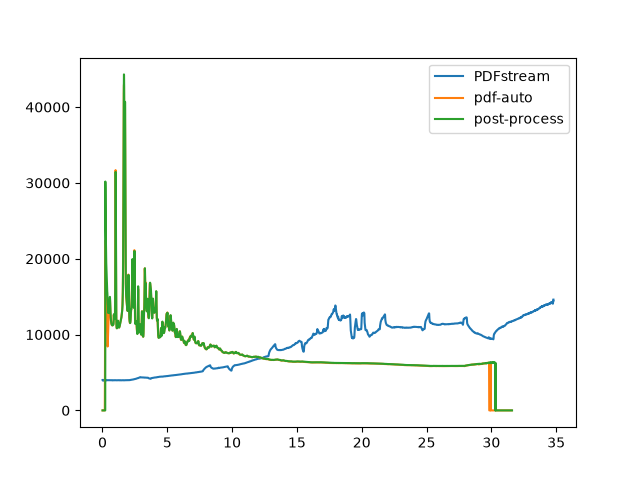

In [21]:
labels = ['PDFstream', 'pdf-auto', 'post-process']
f1, ax1 = plt.subplots(1,1)
for i, df in enumerate([df_01, df_02, df_03]):
    ax1.plot(df['q'], df['I'], label=labels[i])
ax1.legend()